# Analysis of oxygenation of blood & Hb samples with Pyroscience flow probes

We ran PBS through the tubes in the pyroscience sensor, then flushed the blood / haemoglobin samples through, which is why there are plateaus then dips in the data

In [3]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

In [4]:
BASE_PATH = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/Data/pO2_probe_data/'


# Haemoglobin in D20 measured 10/07/2025
Hb_oxy_A = BASE_PATH + '2025-07-10_113033_oxy_A/2025-07-10_113033_oxy_A.txt'
Hb_oxy_B = BASE_PATH + '2025-07-10_114531_oxy_B/2025-07-10_114531_oxy_B.txt'
Hb_oxy_C = BASE_PATH + '2025-07-10_115051_oxy_C/2025-07-10_115051_oxy_C.txt'

Hb_deoxy_A = BASE_PATH + '2025-07-10_144638_deoxy_A/2025-07-10_144638_deoxy_A.txt'
Hb_deoxy_B = BASE_PATH + '2025-07-10_150956_deoxy_B/2025-07-10_150956_deoxy_B.txt'
Hb_deoxy_C = BASE_PATH + '2025-07-10_153255_deoxy_C/2025-07-10_153255_deoxy_C.txt'

# Whole blood measured 10/07/25 for reference
whole_A = BASE_PATH + '2025-07-10_163232_Whole_blood_A/2025-07-10_163232_Whole_blood_A.txt'
whole_10mL = BASE_PATH + '2025-07-10_163417_Whole_blood_10mL'

# 11/07/2025
oxy_A = BASE_PATH + '2025-07-11_145921_oxy_A/2025-07-11_145921_oxy_A.txt'
oxy_bigblood = BASE_PATH + '2025-07-11_150127_oxy_bigblood/2025-07-11_150127_oxy_bigblood.txt'
oxy_bigblood_1pc = BASE_PATH + '2025-07-11_155432_oxy_big1percentblood/2025-07-11_155432_oxy_big1percentblood.txt'

deoxy_wb_A = BASE_PATH + '2025-07-11_171355_deoxy_wholebloodA/2025-07-11_171355_deoxy_wholebloodA.txt'
deoxy_wb_B = BASE_PATH + '2025-07-11_172739_deoxy_wholebloodB/2025-07-11_172739_deoxy_wholebloodB.txt'
deoxy_wb_C = BASE_PATH + '2025-07-11_174040_deoxy_wholebloodC/2025-07-11_174040_deoxy_wholebloodC.txt'

deoxy_1pc_A = BASE_PATH + '2025-07-11_181421_deoxy_1percentA/2025-07-11_181421_deoxy_1percentA.txt'
deoxy_1pc_B = BASE_PATH + '2025-07-11_182507_deoxy_1percentB/2025-07-11_182507_deoxy_1percentB.txt'
deoxy_1pc_C = BASE_PATH + '2025-07-11_183311_deoxy_1percentC/2025-07-11_183311_deoxy_1percentC.txt'

In [5]:
# load txt files
#df = pd.read_csv(path, sep=",", skiprows=0, header=0)
def severinghaus(po2):
    """
    :param po2: Partial Pressure in units of mmHg
    :return so2: Haemoglobin Saturation
    """
    so2 = 100*po2/(po2+23400/(po2**2+100))
    return so2

def find_so2(path):

    df = pd.read_csv(path, delimiter = "\t", skiprows=41, header=0, encoding='ISO-8859-1')

    time = df[' dt (s) [A Ch.1 Main]']

    oxygen_hPa = df['Oxygen (hPa) [A Ch.1 Main]']
    # 1.33 hPa = 1 mmHg
    oxygen_mmHg = oxygen_hPa / 1.33

    min_mmHg = np.min(oxygen_mmHg)
    max_mmHg = np.max(oxygen_mmHg)
    
    print('min po2 = ', round(min_mmHg, 2), 'mmHg')
    print('max po2 = ', round(max_mmHg, 2), 'mmHg')

    # calculate so2 [%]
    so2_min = severinghaus(min_mmHg)
    so2_max = severinghaus(max_mmHg)

    print('min so2 = ', round(so2_min, 2), '%')
    print('max so2 = ', round(so2_max, 2), '%')

    plt.figure(figsize=(5,3))
    plt.plot(time, oxygen_mmHg, ls='-', marker='.', markersize='3', c='k')
    
    plt.xlabel('Time (s)')
    plt.ylabel('Oxygen (mmHg)')

    return so2_min, so2_max


#print(df.columns)
#print(df.dtypes)

# Haemoglobin in D2O

min po2 =  150.64 mmHg
max po2 =  155.65 mmHg
min so2 =  99.32 %
max so2 =  99.39 %
min po2 =  151.61 mmHg
max po2 =  158.14 mmHg
min so2 =  99.34 %
max so2 =  99.41 %
min po2 =  152.04 mmHg
max po2 =  158.27 mmHg
min so2 =  99.34 %
max so2 =  99.42 %


(99.34149209179965, 99.41552880416768)

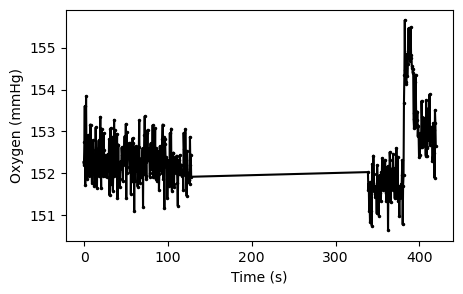

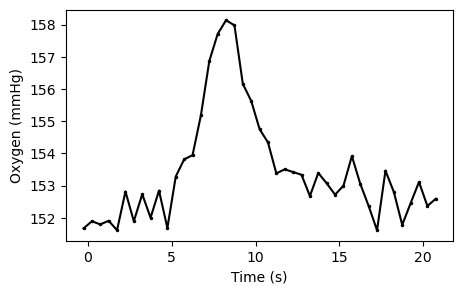

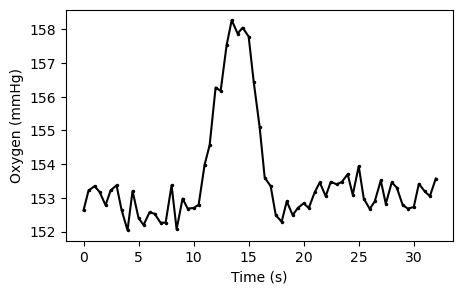

In [6]:
# Hb in D2O 10/07/2025
find_so2(Hb_oxy_A)
find_so2(Hb_oxy_B)
find_so2(Hb_oxy_C)

# Deoxygenated haemoglobin in D2O

min po2 =  0.03 mmHg
max po2 =  152.07 mmHg
min so2 =  0.01 %
max so2 =  99.34 %
min po2 =  0.88 mmHg
max po2 =  152.02 mmHg
min so2 =  0.38 %
max so2 =  99.34 %
min po2 =  -1.09 mmHg
max po2 =  151.42 mmHg
min so2 =  -0.47 %
max so2 =  99.33 %


(-0.4719998110540872, 99.33336516172379)

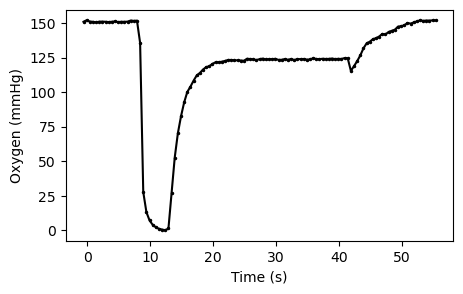

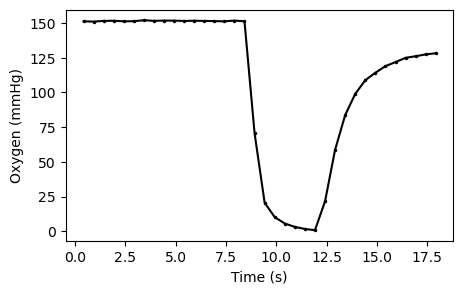

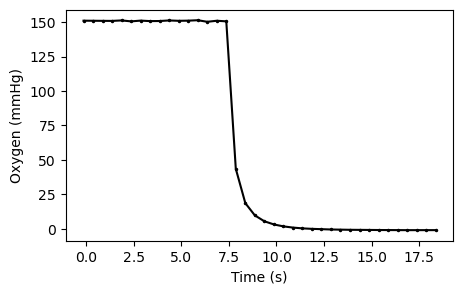

In [7]:
# deoxygenated Hb in D2O 10/07/2025
find_so2(Hb_deoxy_A)
find_so2(Hb_deoxy_B)
find_so2(Hb_deoxy_C)

# Whole blood

min po2 =  104.01 mmHg
max po2 =  149.6 mmHg
min so2 =  97.98 %
max so2 =  99.31 %


(97.98111496988211, 99.30897627638988)

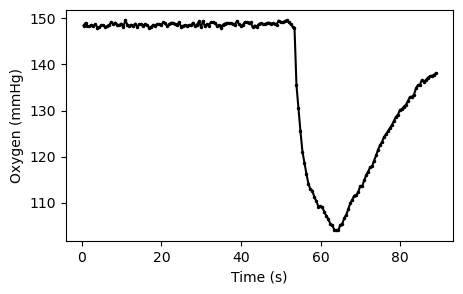

In [8]:
# whole blood not oxygenated 11/07/2025
find_so2(oxy_A)

# Whole blood

min po2 =  107.95 mmHg
max po2 =  152.29 mmHg
min so2 =  98.19 %
max so2 =  99.34 %


(98.18894693416136, 99.34470410094278)

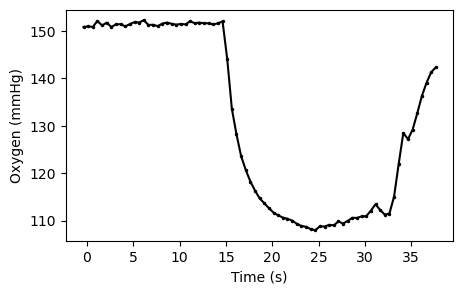

In [9]:
# reference from 10/07/2025
find_so2(whole_A)

# Whole blood

min po2 =  98.26 mmHg
max po2 =  145.63 mmHg
min so2 =  97.62 %
max so2 =  99.25 %


(97.61715841308137, 99.25157142561753)

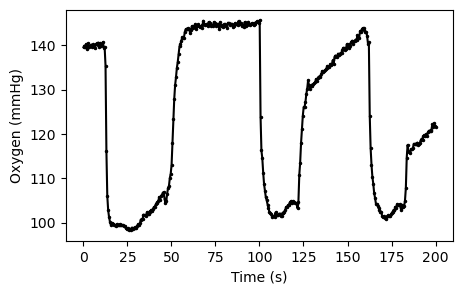

In [10]:
# whole blood not oxygenated 11/07/2025
find_so2(oxy_bigblood)

# 1% whole blood, 99% PBS

min po2 =  147.03 mmHg
max po2 =  152.82 mmHg
min so2 =  99.27 %
max so2 =  99.35 %


(99.27255151045827, 99.35140751234161)

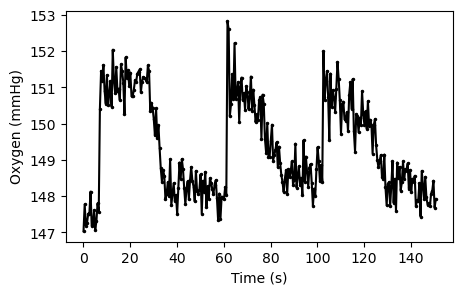

In [11]:
# reference from 11/07/2025
find_so2(oxy_bigblood_1pc)

# Deoxygenated whole blood

min po2 =  2.5 mmHg
max po2 =  149.15 mmHg
min so2 =  1.12 %
max so2 =  99.3 %
min po2 =  -1.19 mmHg
max po2 =  148.48 mmHg
min so2 =  -0.52 %
max so2 =  99.29 %
min po2 =  -1.21 mmHg
max po2 =  148.74 mmHg
min so2 =  -0.53 %
max so2 =  99.3 %


(-0.5273303486314779, 99.2970284616444)

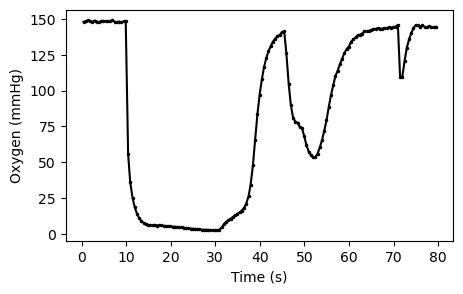

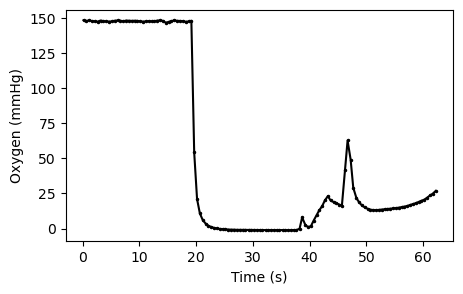

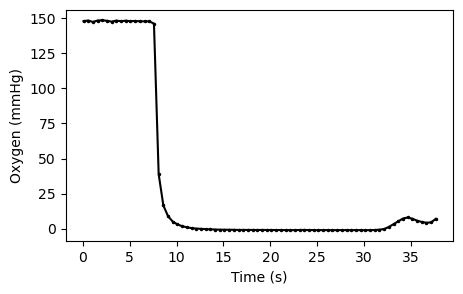

In [12]:
find_so2(deoxy_wb_A)
find_so2(deoxy_wb_B)
find_so2(deoxy_wb_C)

# 1% whole blood, 99% PBS, deoxygenated 

min po2 =  -1.31 mmHg
max po2 =  148.79 mmHg
min so2 =  -0.57 %
max so2 =  99.3 %
min po2 =  -1.25 mmHg
max po2 =  149.24 mmHg
min so2 =  -0.55 %
max so2 =  99.3 %
min po2 =  -1.08 mmHg
max po2 =  147.05 mmHg
min so2 =  -0.47 %
max so2 =  99.27 %


(-0.4696493560869367, 99.27275027860414)

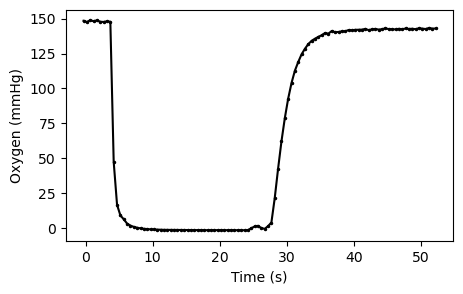

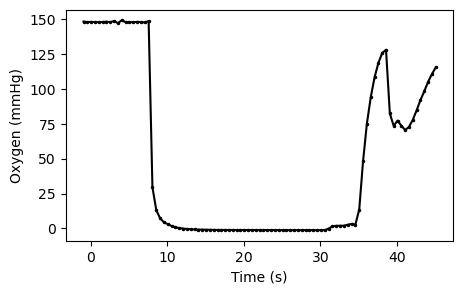

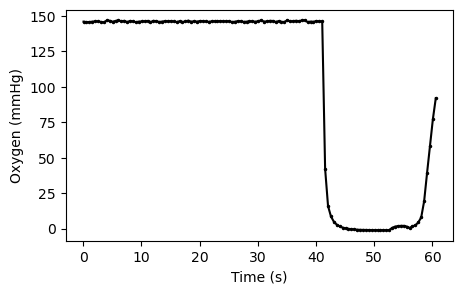

In [14]:
find_so2(deoxy_1pc_A)
find_so2(deoxy_1pc_B)
find_so2(deoxy_1pc_C)